# 1. Import the required libraries

In [2]:
# Standard code libraries
import os

import matplotlib.pyplot as plt
import numpy as np

from resurfemg.data_connector import file_discovery

# Custom code libraries from ReSurfEMG
from resurfemg.data_connector.config import Config
from resurfemg.data_connector.tmsisdk_lite import Poly5Reader
from resurfemg.pipelines import ipy_widgets
from resurfemg.pipelines.processing import quick_look

config = Config()

%matplotlib widget

INFO:resurfemg.data_connector.config:Failed to load config.json: [Errno 2] No such file or directory: 'config.json'
INFO:resurfemg.data_connector.config:Failed to load /Users/chiaramaninetti/.resurfemg/config.json: [Errno 2] No such file or directory: '/Users/chiaramaninetti/.resurfemg/config.json'
INFO:resurfemg.data_connector.config:Failed to load /etc/resurfemg/config.json: [Errno 2] No such file or directory: '/etc/resurfemg/config.json'
INFO:resurfemg.data_connector.config:Loaded config from: /Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/config.json


## 2. Load sEMG test data

## Synthetic data

In [3]:
# For the test data:
base_path = config.get_directory("test_data")

files = file_discovery.find_files(
    base_path=base_path, file_name_regex="*", extension_regex="Poly5", folder_levels=None, verbose=False
)
button_list = ipy_widgets.file_select(
    files=files, folder_levels=["files"], default_value_select=None, default_idx_select=[0]
)

interactive(children=(Dropdown(description='files:', options=('emg_data_synth_pocc.Poly5', 'emg_data_synth_qui…

In [4]:
# Load the EMG from the selected folders (synthetic data):
emg_file_chosen = os.path.join(base_path, *[btn.value for btn in button_list])

data_emg = Poly5Reader(emg_file_chosen)
data_emg_samples = data_emg.samples[: data_emg.num_samples]
fs_emg = data_emg.sample_rate

y_emg = data_emg_samples
t_emg = [i / fs_emg for i in range(len(y_emg[0, :]))]

INFO:resurfemg.data_connector.tmsisdk_lite:Reading file /Users/chiaramaninetti/Documents/M3RESP/ReSurfEMG/test_data/emg_data_synth_pocc.Poly5
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  860160 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  2 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 2048 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.


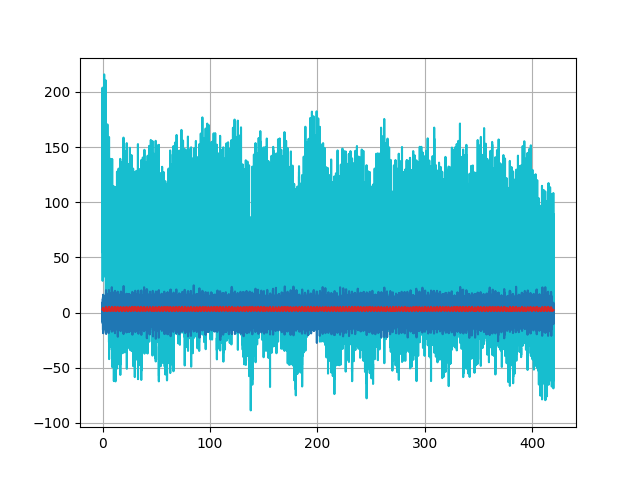

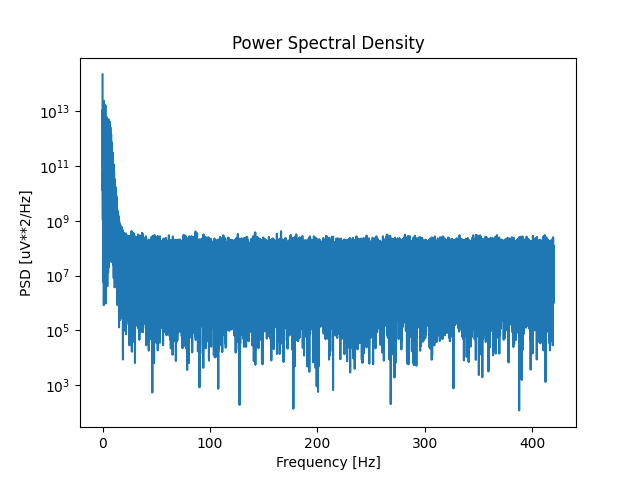

In [5]:
_ = quick_look(y_emg[1, :], fs_emg=fs_emg, plot_raw=True)